# Sudoku Solver

**Prepared by:** William Bartel (wbartel@nd.edu, 2024) and Andrew Brooks (abrooks7@nd.edu, 2024). Adapted from material by Prof. Alexander Dowling and Elvis Eugene at the University of Notre Dame

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 23 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

## Learning Objectives
* Formulating a sudoku puzzle as a mixed-integer feasibility problem
* Reading a committed dataset of randomly generated puzzles
* Visualizing a puzzle's starting position alongside its solution
* Comparing two MILP solvers, and seeing how the model size scales


## Imports

In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

# Import Libraries
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from matplotlib.patches import Rectangle

# This notebook draws no random numbers: the puzzles are read from committed
# CSV files. Generating those files IS random, and that code is seeded --
# see scripts/generate_sudoku_puzzles.py in the course repository.

## Defining Sudoku Puzzles


Sudoku puzzles are one of the most widely known logical puzzles. The rules of a sudoku puzzle are simple. For an $n \times n$ puzzle, each row, each column, and each subsquare must have exactly one of each number 1 through $n$. One can look at the numbers given in the puzzle and use logic to conclude which squares must contain which numbers. An example puzzle is shown below.

![A 9 by 9 sudoku puzzle on the left, with about half of its cells blank, and the same puzzle completed on the right, where the filled-in digits are printed in red and the digits that were given are printed in black.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/sudoku_puzzle_and_solution.jpg)


### Formulating an Optimization Problem for $n\times n$ Puzzle




**Sets:**
* Rows $R=\{1,2, ...,n\}$
* Columns $C=\{1,2, ...,n\}$
* Values $V=\{1,2, ...,n\}$
* Subgrids $K=\{1,2, ...,n\}$

**Parameters:**
* $s_{v,i,j} = $ is value $v$ present in box located at $(i,j)$ from unsolved puzzle for $i\in R, j\in C, v \in V$. (Binary)
* $SG_{i} = $ coordinate pairs for the boxes in each subgrid for $i\in K$

**Variables:**
* $y_{v,i,j} = $ is value $v$ present in box located at $(i,j)$ when creating solved puzzle for $i\in R, j\in C, v \in V$. (Binary)


**Objective:**
* $\min 0$

**Constraints:**

$$\sum_{j\in C}y_{v,i,j}=1, \forall i\in R, v\in V$$

$$\sum_{i\in R}y_{v,i,j}=1, \forall j\in C, v\in V$$

$$\sum_{(i,j)\in SG[\ l \ ]}y_{v,i,j}=1, \forall l\in K, v\in V$$

$$\sum_{v\in V}y_{v,i,j}=1, \forall i\in R, j\in C$$

$$y_{v,i,j} * s_{v,i,j} = s_{v,i,j}, \forall i\in R, j\in C, v\in V$$

Because the problem is a feasibility problem and there is only one possible answer, no objective is needed and thus the objective is a constant, in this case 0.

The constraints are described as follows:

1. There can only be one instance of each possible value in each row.
2. There can only be one instance of each possible value in each column.
3. There can only be one instance of each possible value in each subgrid.
4. There can only be one value in each square.
5. Each value given by the unsolved puzzle must be the same in the solved puzzle.

In [2]:
# Define class 'Puzzle' to store an unsolved or solved sudoku board
# Stores size of puzzle, grid values, and subgrid coordinates


class Puzzle:
    """One sudoku board: its size, its cells, and its subgrid geometry.

    Arguments:
        board: an n-by-n nested list (or array) of ints, 1..n for a filled
            cell and 0 for a blank one
    """

    def __init__(self, board):

        # n = number of rows = number of columns
        n = len(board[0])
        # side length of one subgrid
        sub = int(math.sqrt(n))

        self.size = n
        self.grid = [list(int(v) for v in row) for row in board]

        # s[(v,r,c)] = 1 if the cell in position (r,c) has value v
        # s[(v,r,c)] = 0 otherwise
        # Note: rows and columns begin at 1 and end at n
        self.params = {
            (v, r, c): int(self.grid[r - 1][c - 1] == v)
            for v in range(1, n + 1)
            for r in range(1, n + 1)
            for c in range(1, n + 1)
        }

        # subgrids[i] = collection of ordered pairs (r,c) such that (r,c) is in
        # the i-th subgrid. Subgrids are sqrt(n) by sqrt(n) and are indexed top
        # to bottom, then left to right.
        self.subgrids = {
            i: [
                (r, c)
                for r in range(1 + sub * ((i - 1) % sub), 1 + sub * ((i - 1) % sub + 1))
                for c in range(
                    1 + sub * ((i - 1) // sub),
                    1 + sub * ((i - 1) // sub + 1),
                )
            ]
            for i in range(1, n + 1)
        }

## The Sudoku Datasets


The puzzles used below were generated ahead of time and are committed to the course repository as `notebooks/data/sudoku_puzzles_4.csv`, `..._9.csv`, `..._16.csv`, `..._25.csv` and `..._36.csv`. Each file holds 100 puzzles of one size, one puzzle per row, flattened row-major, with `0` for a blank cell.

The generator itself is **not** in this notebook. It lives in `scripts/generate_sudoku_puzzles.py`, it is seeded, and re-running it reproduces the committed CSV files byte for byte:

```bash
python scripts/generate_sudoku_puzzles.py            # rewrite the CSV files
python scripts/generate_sudoku_puzzles.py --check    # verify, write nothing
```

How it works, in one paragraph. It starts from a stored *solved* board for each of $n=4,9,16,25,36$ and scrambles it with moves that preserve the sudoku property: interchanging two rows that pass through the same band of subgrids, interchanging two whole bands of rows, and the two column analogues. Any composition of those maps a solved board to a different solved board. It then blanks out a size-dependent number of cells to make the puzzle.


For instance, `swap_cols_within_band` interchanges two columns that pass through the same subgrids.

![A 9 by 9 solved sudoku with two columns inside the middle band of subgrids highlighted, and the same board on the right after those two columns have been interchanged; the result is still a valid solved sudoku.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/sudoku_column_swap.jpg)

:::{note}
This construction does **not** guarantee that a puzzle has a unique solution --- see the Conclusion. A puzzle with several completions is still a perfectly good MILP feasibility instance, which is all we ask of it here.
:::


### Reading the Puzzles

`load_puzzles` reads one CSV file and returns every puzzle in it as an array of shape `(number of puzzles, n, n)`. On Google Colab the relative path below is rewritten to a `raw.githubusercontent.com` URL when the notebook is published, so the data downloads automatically and nothing else has to change.

In [3]:
def load_puzzles(size):
    """Read every puzzle of one size from the committed dataset.

    Arguments:
        size: puzzle side length n, one of 4, 9, 16, 25, 36

    Returns:
        an integer array of shape (number of puzzles, size, size); 0 is a blank
    """
    table = pd.read_csv(f"https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/sudoku_puzzles_{size}.csv", header=None)
    return table.to_numpy(dtype=int).reshape(-1, size, size)


# Read the first 9 by 9 puzzle in the dataset
puzzles_9 = load_puzzles(9)
print(f"{len(puzzles_9)} puzzles of size 9 x 9")
print(puzzles_9[0])

100 puzzles of size 9 x 9
[[3 2 0 0 8 1 0 0 7]
 [1 0 0 7 2 6 3 0 0]
 [6 8 0 3 0 5 9 0 0]
 [2 6 8 4 0 3 1 7 9]
 [4 0 0 0 0 0 0 3 0]
 [5 0 3 6 1 9 0 0 4]
 [8 0 5 2 0 0 7 9 1]
 [9 4 2 0 0 7 8 5 6]
 [7 1 6 0 0 8 0 0 3]]


## Sudoku Optimization Solver


Below is the optimization formulation to solve a sudoku puzzle. The formulation was described earlier. Following the [Pyomo style guide](https://ndcbe.github.io/optimization/org/pyomo-style-guide.html), the model is assembled by a function that takes data and returns a fresh `ConcreteModel`, and the solve is a separate step.

In [4]:
def build_sudoku_model(puzzle):
    """Build the MILP feasibility model for one sudoku puzzle.

    Arguments:
        puzzle: a Puzzle holding the starting position

    Returns:
        a Pyomo ConcreteModel
    """
    m = pyo.ConcreteModel()

    n = puzzle.size

    # Index sets. All four run 1..n; they are declared separately because they
    # mean different things, and m.pprint() then says which is which.
    m.VALUES = pyo.RangeSet(1, n)
    m.ROWS = pyo.RangeSet(1, n)
    m.COLS = pyo.RangeSet(1, n)
    m.SUBGRIDS = pyo.RangeSet(1, n)

    # Is value v printed in cell (r,c) of the starting puzzle? s_{v,i,j} [-]
    m.given = pyo.Param(
        m.VALUES, m.ROWS, m.COLS, initialize=puzzle.params, domain=pyo.Binary
    )

    # Does cell (r,c) hold value v in the completed puzzle? y_{v,i,j} [-]
    m.y = pyo.Var(m.VALUES, m.ROWS, m.COLS, domain=pyo.Binary, initialize=0)

    # The DECLARATION ORDER of the five constraints below is deliberate: it
    # fixes the row order of the LP file handed to the solver, and CBC's
    # branch-and-bound is sensitive to it. Reordering these (subgrid before
    # cell) leaves the model mathematically identical but made the hardest
    # 36 x 36 puzzle in the dataset take over ten minutes instead of about
    # one. Measured 2026-08-25; the LP file is byte-identical in this order.

    @m.Constraint(m.VALUES, m.ROWS)
    def one_per_row(b, v, r):
        """Value v appears exactly once in row r."""
        return sum(b.y[v, r, c] for c in b.COLS) == 1

    @m.Constraint(m.VALUES, m.COLS)
    def one_per_col(b, v, c):
        """Value v appears exactly once in column c."""
        return sum(b.y[v, r, c] for r in b.ROWS) == 1

    @m.Constraint(m.ROWS, m.COLS)
    def one_value_per_cell(b, r, c):
        """Cell (r,c) holds exactly one value."""
        return sum(b.y[v, r, c] for v in b.VALUES) == 1

    @m.Constraint(m.VALUES, m.ROWS, m.COLS)
    def match_given(b, v, r, c):
        """A value printed in the starting puzzle carries into the solution."""
        return b.y[v, r, c] * b.given[v, r, c] == b.given[v, r, c]

    @m.Constraint(m.VALUES, m.SUBGRIDS)
    def one_per_subgrid(b, v, k):
        """Value v appears exactly once in subgrid k."""
        return sum(b.y[v, r, c] for (r, c) in puzzle.subgrids[k]) == 1

    # A sudoku is a feasibility problem: any completion is as good as any other
    m.obj = pyo.Objective(expr=0)

    return m


def solve_sudoku(puzzle, solver="appsi_highs", tee=False):
    """Build and solve the sudoku MILP.

    Arguments:
        puzzle: a Puzzle holding the starting position
        solver: a SolverFactory name; this notebook uses "appsi_highs" and "cbc"
        tee: show the solver log

    Returns:
        the solved Pyomo ConcreteModel
    """
    m = build_sudoku_model(puzzle)

    opt = pyo.SolverFactory(solver)
    results = opt.solve(m, tee=tee)

    # Never touch pyo.value() before checking the termination condition
    assert pyo.check_optimal_termination(results), (
        f"Solve failed: status={results.solver.status}, "
        f"termination={results.solver.termination_condition}"
    )

    return m


def extract_solution(model, puzzle):
    """Pull the completed grid out of a solved model.

    Separating extraction from plotting is the house convention: the solve is
    expensive, the picture is not, so the numbers come out once and the figure
    can be redrawn as often as you like.

    Arguments:
        model: a solved model from solve_sudoku
        puzzle: the Puzzle it was built from

    Returns:
        an n-by-n nested list of ints, the completed grid
    """
    n = puzzle.size
    grid = [[0] * n for _ in range(n)]
    for v, r, c in model.y:
        # HiGHS can return 0.9999... or -0.0 for a binary; compare with a
        # tolerance, never with == 1
        if pyo.value(model.y[v, r, c]) >= 0.5:
            grid[r - 1][c - 1] = v
    return grid

### Visualizing a Puzzle and Its Solution

`plot_sudoku` draws one board. Given a solution as well, it draws the completed board with the **starting pieces distinguished from the cells the solver filled in** --- which is the interesting part of the picture, because it shows how much of the puzzle the solver actually had to do.

The distinction is carried three ways, not one: the given cells sit on a **shaded background**, their digits are set in **bold**, and they are **black** where the solved digits are vermillion. That redundancy is the course figure rule --- a distinction may be carried by color, but never by color *alone*, because students print these handouts on black-and-white printers. See [`figures/README.md`](https://github.com/ndcbe/optimization/blob/main/figures/README.md).

In [5]:
# Okabe-Ito vermillion, the same color the house style cycles second.
# Color is the third cue here, not the only one: see the docstring.
SOLVED_COLOR = "#D55E00"
GIVEN_SHADE = "0.87"


def plot_sudoku(puzzle, solution=None, ax=None, title=None):
    """Draw a sudoku board, distinguishing the givens from the solved cells.

    Arguments:
        puzzle: a Puzzle holding the starting position
        solution: a completed grid from extract_solution, or None to draw only
            the starting position
        ax: an Axes to draw on, or None to create a new figure
        title: axes title

    Returns:
        the Axes drawn on

    Givens and solved cells are told apart three ways so the figure survives
    grayscale printing: the givens are shaded, bold and black; the solved cells
    are unshaded, regular weight and vermillion.
    """
    n = puzzle.size
    sub = int(math.sqrt(n))

    if ax is None:
        side = 1.0 + 0.32 * n
        _, ax = plt.subplots(figsize=(side, side))

    # Cell (r,c), 1-indexed from the top left, occupies the unit square with
    # lower-left corner (c-1, n-r) so that row 1 is drawn at the top.
    for r in range(1, n + 1):
        for c in range(1, n + 1):
            given = puzzle.grid[r - 1][c - 1]
            if given:
                ax.add_patch(
                    Rectangle(
                        (c - 1, n - r),
                        1,
                        1,
                        facecolor=GIVEN_SHADE,
                        edgecolor="none",
                        zorder=0,
                    )
                )

    fontsize = max(4.5, 95.0 / n)
    for r in range(1, n + 1):
        for c in range(1, n + 1):
            given = puzzle.grid[r - 1][c - 1]
            value = given if given else (solution[r - 1][c - 1] if solution else 0)
            if not value:
                continue
            ax.text(
                c - 0.5,
                n - r + 0.5,
                str(value),
                ha="center",
                va="center",
                fontsize=fontsize,
                fontweight="bold" if given else "normal",
                color="black" if given else SOLVED_COLOR,
                zorder=2,
            )

    # Grid lines: heavy on the subgrid boundaries, light inside them
    for i in range(n + 1):
        lw = 2.0 if i % sub == 0 else 0.6
        ax.axhline(i, color="black", linewidth=lw, zorder=1)
        ax.axvline(i, color="black", linewidth=lw, zorder=1)

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12)
    return ax

### A Worked Example

The 9 by 9 board below is the one drawn at the top of this notebook. We keep it as a named constant rather than reading it from the dataset precisely because it is a *worked example*: it has to stay the same board as the figure. Every other puzzle in this notebook comes from the CSV files.

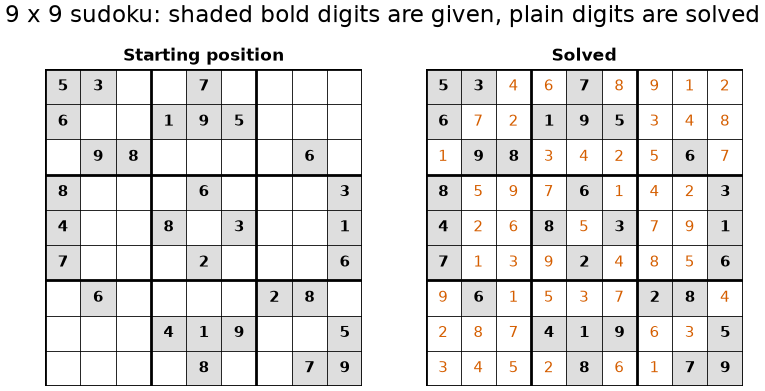

In [6]:
# The 9 by 9 puzzle drawn in the figure at the top of this notebook.
# A worked example, deliberately hardcoded so it cannot drift from that figure.
EXAMPLE_PUZZLE_9 = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

example = Puzzle(EXAMPLE_PUZZLE_9)
model = solve_sudoku(example)
solution = extract_solution(model, example)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
plot_sudoku(example, ax=axes[0], title="Starting position")
plot_sudoku(example, solution=solution, ax=axes[1], title="Solved")
fig.suptitle("9 x 9 sudoku: shaded bold digits are given, plain digits are solved")
plt.show()

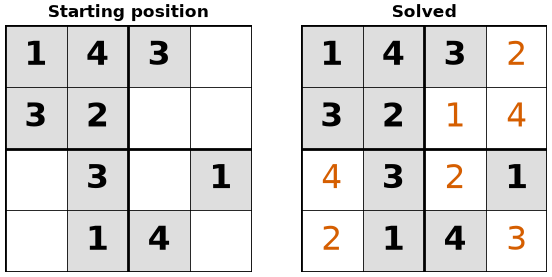

In [7]:
# The same two pictures for a 4 by 4 puzzle read from the dataset

small = Puzzle(load_puzzles(4)[0])
small_solution = extract_solution(solve_sudoku(small), small)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.8))
plot_sudoku(small, ax=axes[0], title="Starting position")
plot_sudoku(small, solution=small_solution, ax=axes[1], title="Solved")
plt.show()

## Computing Average Sudoku Solve Times

For a given positive integer $a\geq2$, let $n=a^2$. We are curious how the complexity of solving an $n\times n$ sudoku scales. It is fair to hypothesize that the complexity scales at a superlinear rate, given that the number of cells in an $n\times n$ sudoku is $n^2=a^4$, and the number of *binary variables* --- one per (value, row, column) triple --- is $n^3$.

Our goal is to test two solvers (HiGHS and CBC) to determine which solver, if any, is fastest at solving sudokus. The following program reads the first 10 puzzles of each size from the committed CSV files. The number read can be modified (`iterations` below), but it is set to 10 by default for a quick computation time.

We test the average solve time for an $n\times n$ sudoku for $a=2,3,4,5,6$, and we record the number of binary variables in each model at the same time so the two can be plotted together.

In [8]:
# Computes the average time to build and solve a sudoku of each size

# Set iterations to a number from 1 to the number of puzzles in the CSV file
# (100 by default). Determines how many puzzles go into each average.
# A full run of this cell takes roughly 3-4 minutes, almost all of it CBC at
# n = 36. Drop 36 from `sizes` for a much faster run.
iterations = 10

sizes = [4, 9, 16, 25, 36]

# DELIBERATE EXCEPTION to the course default. Everywhere else in this repo we
# call HiGHS ("appsi_highs") for LPs and MILPs -- see org/pyomo-style-guide.md,
# section 7a. This cell keeps "cbc" because BENCHMARKING THE TWO IS THE POINT of
# this section; the conclusion below is drawn from the comparison. Do not
# "standardise" this list.
solvers = ["appsi_highs", "cbc"]

# Read every dataset once, rather than once per solve
datasets = {size: load_puzzles(size) for size in sizes}

# Number of binary variables in the model, counted from Pyomo rather than
# assumed. The prose below claims this is n**3; the assertion checks it.
binary_counts = []
for size in sizes:
    m = build_sudoku_model(Puzzle(datasets[size][0]))
    n_binary = sum(1 for v in m.component_data_objects(pyo.Var) if v.is_binary())
    assert n_binary == size**3, f"{size}: {n_binary} binaries, expected {size**3}"
    binary_counts.append(n_binary)

print("size  binary variables")
for size, n_binary in zip(sizes, binary_counts):
    print(f"{size:4d}  {n_binary:16,d}")
print()

# Average wall-clock time to build and solve, per solver and size
average_times = {}

for solver in solvers:
    averages = []
    print(f"For the solver {solver}:")
    for size in sizes:
        times = []
        for i in range(iterations):
            puzzle = Puzzle(datasets[size][i])

            start_time = time.time()
            solve_sudoku(puzzle, solver=solver)
            times.append(time.time() - start_time)

        averages.append(sum(times) / len(times))
        print(f"  Average time for {size} by {size} sudoku: {averages[-1]:.5f} s")
    average_times[solver] = averages
    print()

size  binary variables
   4                64
   9               729
  16             4,096
  25            15,625
  36            46,656

For the solver appsi_highs:


  Average time for 4 by 4 sudoku: 0.00529 s


  Average time for 9 by 9 sudoku: 0.02751 s


  Average time for 16 by 16 sudoku: 0.14794 s


  Average time for 25 by 25 sudoku: 0.52916 s


...

  Average time for 4 by 4 sudoku: 0.07930 s


  Average time for 9 by 9 sudoku: 0.09627 s


  Average time for 16 by 16 sudoku: 0.20839 s


  Average time for 25 by 25 sudoku: 0.53489 s


  Average time for 36 by 36 sudoku: 17.03840 s



### Solve Time and Model Size

The figure below puts both quantities on one pair of **logarithmic** axes: average solve time on the left, number of binary variables on the right. On log-log axes a power law $y \propto n^p$ is a straight line of slope $p$, so the binary count --- exactly $n^3$, asserted against Pyomo in the cell above --- must plot as a perfectly straight line of slope 3, and the two time curves can be read against it.

log-log slope, binary variables : 3.0000  (n**3 predicts 3)
log-log slope, appsi_highs : 2.61
log-log slope, cbc         : 2.09


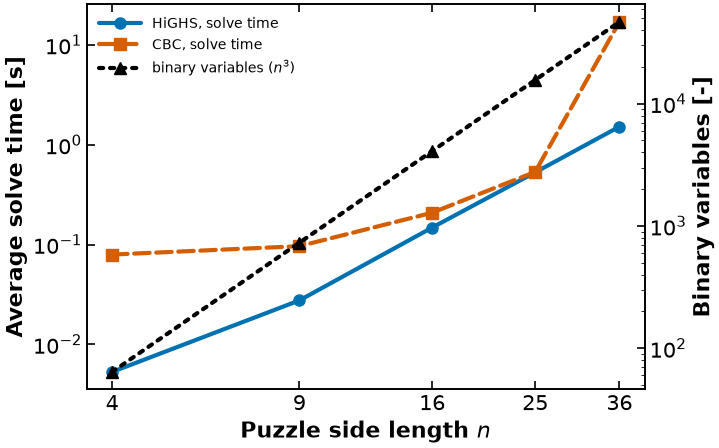

In [9]:
# Least-squares slopes on log-log axes: y ~ n**p plots as a line of slope p
log_sizes = np.log(sizes)
slopes = {s: np.polyfit(log_sizes, np.log(average_times[s]), 1)[0] for s in solvers}
slope_binary = np.polyfit(log_sizes, np.log(binary_counts), 1)[0]

print(f"log-log slope, binary variables : {slope_binary:.4f}  (n**3 predicts 3)")
for s in solvers:
    print(f"log-log slope, {s:12s}: {slopes[s]:.2f}")

fig, ax_time = plt.subplots(figsize=(7.2, 5))

# Two solvers on the left axis. Every series carries a marker AND a linestyle,
# so the figure is still readable printed in black and white.
ax_time.loglog(
    sizes,
    average_times["appsi_highs"],
    color="#0072B2",
    marker="o",
    linestyle="-",
    label="HiGHS, solve time",
)
ax_time.loglog(
    sizes,
    average_times["cbc"],
    color="#D55E00",
    marker="s",
    linestyle="--",
    label="CBC, solve time",
)
ax_time.set_xlabel("Puzzle side length $n$")
ax_time.set_ylabel("Average solve time [s]")

# Model size on the right axis, also logarithmic
ax_binary = ax_time.twinx()
ax_binary.loglog(
    sizes,
    binary_counts,
    color="black",
    marker="^",
    linestyle=":",
    label="binary variables ($n^3$)",
)
ax_binary.set_ylabel("Binary variables [-]")

ax_time.set_xticks(sizes)
ax_time.set_xticklabels([str(s) for s in sizes])
ax_time.minorticks_off()

handles = ax_time.get_lines() + ax_binary.get_lines()
ax_time.legend(handles, [h.get_label() for h in handles], loc="upper left", fontsize=10)
plt.show()

**The binary count is a straight line of slope 3, exactly as predicted**, which is the easy half of the figure: the model has one binary per (value, row, column) triple, so it has $n^3$ of them --- 64 at $n=4$ and 46,656 at $n=36$, a factor of 729 across the sweep. The cell above asserts that count against Pyomo rather than taking it on trust, and prints the fitted slope so you can see it is 3 to within floating point.

The solve times are the interesting half, and they are **not** a straight line. HiGHS is faster than CBC at every size we tested, but for two different reasons at the two ends of the range. On the smallest puzzles the gap is mostly an interface effect rather than a statement about branch-and-bound: `appsi_highs` builds the problem in memory through the `highspy` library, whereas `cbc` is launched as a separate executable and every solve pays a fixed cost to write an LP file and read a solution file back. For $n=4,9,16$ the puzzles are easy enough that this fixed cost dominates --- which is why the CBC curve is nearly flat at the left, and why its fitted slope understates how it actually scales. By $n=25$ the search itself dominates and the two solvers are nearly tied. At $n=36$ they separate again, this time by more than a factor of ten, and that gap *is* about the search.

:::{warning}
**Solve times are a property of the machine, not of the solvers.** They depend on your processor, on how busy it is, on the randomly generated puzzles that happen to be first in each CSV file, and on the solver versions installed. The timings published with this notebook were measured on 2026-08-25 on an Apple silicon macOS laptop, Python 3.13, Pyomo 6.10, HiGHS via `highspy`, and CBC 2.10 from `idaes get-extensions`. The whole cell above took **3 minutes 27 seconds** there, roughly five sixths of it CBC at $n=36$. Re-run it and read your own numbers before drawing any conclusion; do not quote ours.

CBC's time on a single hard puzzle is especially volatile: the first four $36\times36$ puzzles in the file took 62.4 s, 1.2 s, 0.8 s and 1.0 s on the machine above --- one instance accounts for more than a third of the whole sweep. That is why the numbers above are averages over ten puzzles, and it is worth remembering when you compare two solvers on one instance.
:::

## Conclusion


We formulated a sudoku puzzle as an optimization problem, built a function that visualizes a puzzle's starting position beside its solution, and analyzed how scaling the sudoku size affects both the size of the model and the average time it takes to solve. The puzzles themselves come from a committed dataset generated by a separate, seeded script, so every run of this notebook sees the same puzzles.

There are a few different opportunities to build upon this project. First, a more robust random sudoku generator could be created. The algorithm in `scripts/generate_sudoku_puzzles.py` does not ensure that a puzzle has a unique solution. A backtracking algorithm that ensures the solution is unique could be implemented, but we found this to take too much time. A select number of puzzles could also be generated that require different solving techniques, testing the limits of each solver.

Another area for future work is that, as of right now, it takes too long for Colab and our solver to efficiently solve an $n\times n$ puzzle for $n\geq49$. This could be addressed by finding ways to improve the efficiency of our algorithms or by using a faster computer.

One last area for future work is testing other solvers for this problem. Commercial solvers such as CPLEX, which has an optimized branch-and-bound algorithm, and Gurobi, which has a branch-and-cut algorithm along with other helpful features, are designed to work well with MILP problems of differing sizes and complexities and could be investigated as good solvers for this problem.

In this project, we were able to create an effective sudoku puzzle solver that visualizes its solutions. Furthermore, we showed that the number of binary variables grows exactly as $n^3$, and that solve time grows faster still --- a superlinear relationship between problem size and solver time.